# Análisis exploratorio — detección de fraude eléctrico en clientes de STEG

Este cuaderno recorre las fases 0 a 2 del proyecto sobre los datos de facturación de la
Tunisian Company of Electricity and Gas: qué contienen los archivos, qué problemas de
calidad tienen, cómo se distribuye cada variable, cómo se relacionan con la etiqueta de
fraude y qué implica todo ello para el protocolo de evaluación.

El orden de trabajo es deliberado. Primero se entiende qué representa cada tabla y cada
columna; después se inspecciona el contenido real; luego se detectan y cuantifican los
defectos; y solo al final se exploran relaciones. Ningún análisis se ejecuta por
costumbre: cada uno responde una pregunta que el paso anterior dejó abierta, y los que no
aportaron nada se mencionan sin desarrollarlos.

Dos reglas gobiernan lo que sigue. Todo análisis que mire la etiqueta corre
exclusivamente sobre la partición de entrenamiento, porque la de prueba no la tiene y
mezclarlas contaminaría cualquier evaluación posterior. Y ninguna anomalía se corrige
aquí: esta fase identifica y estudia problemas, mientras que el tratamiento se propone
para etapas posteriores y se registra con su evidencia en `reports/DECISIONS.md`.

Las salidas quedan en `reports/EDA/` (informes), `reports/tables/` (cifras) y
`reports/figures/` (figuras). Ninguna cifra citada en el texto se escribe a mano: todas
salen de los objetos que estas celdas calculan.

In [ ]:
from __future__ import annotations

import json
import sys
import warnings
from datetime import date
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

from steg.config import (  # noqa: E402
    INTERIM_FILES,
    N_FOLDS,
    REPORTS_EDA_DIR,
    REPORTS_FIGURES_DIR,
    REPORTS_TABLES_DIR,
    SEED,
)
from steg.data.split import grouped_kfold_splits  # noqa: E402
from steg.eda import bivariate as biv  # noqa: E402
from steg.eda import figures as fg  # noqa: E402
from steg.eda import univariate as uni  # noqa: E402

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)

fg.apply_style()
rng = np.random.default_rng(SEED)

TABLES = REPORTS_TABLES_DIR
FIGURES = REPORTS_FIGURES_DIR
EDA = REPORTS_EDA_DIR
for d in (TABLES, FIGURES, EDA):
    d.mkdir(parents=True, exist_ok=True)

CONS = [f"consommation_level_{i}" for i in range(1, 5)]
FLAGS = [
    "logical_duplicate",
    "counter_statue_invalid",
    "reading_remarque_invalid",
    "months_number_invalid",
    "index_regression",
]

def num(v, dec: int | None = None) -> str:
    "Número en convención española: punto de millar y coma decimal."
    if isinstance(v, str):
        return v
    if dec is not None:
        s = f"{float(v):.{dec}f}"
    elif isinstance(v, (int, np.integer)) or float(v).is_integer():
        return uni.mil(v)
    else:
        s = f"{float(v):.4g}"
    entero, _, frac = s.partition(".")
    entero = f"{int(entero):,}".replace(",", ".")
    return f"{entero},{frac}" if frac else entero


def guardar(df: pd.DataFrame, nombre: str, index: bool = False) -> pd.DataFrame:
    "Escribe una tabla en reports/tables/ y la devuelve, para encadenar en una celda."
    df.to_csv(TABLES / f"{nombre}.csv", index=index)
    return df

print("semilla:", SEED, "| folds por defecto:", N_FOLDS)
print("versiones:", pd.__version__, np.__version__)

semilla: 42 | folds por defecto: 5
versiones: 2.3.2 2.3.3


## 1. Qué representan estos datos

Antes de mirar una sola distribución conviene fijar qué es cada fila, porque el resto del
análisis depende de ello. 
Se tienen 2 tablas (cada una con train y test).

En `client_train` cada fila es un cliente: su distrito, su región, la
categoría a la que pertenece y la fecha en que se dio de alta. En esta se trae la variable objetivo 
 `target`, donde 1 marca al cliente identificado como defraudador.

En `invoice_train` cada fila es una factura emitida a un cliente, con la
fecha, el tipo de tarifa, identificadores del contador, el estado en que lo encontró el
operario, la lectura anterior y la nueva, el consumo desglosado en cuatro niveles
tarifarios y el número de meses que cubre el documento.

La relación entre ambas es uno a muchos por `client_id`. La etiqueta vive en la tabla de
clientes y el comportamiento en la de facturas, de modo que cualquier modelo tendrá que
resumir un historial de longitud variable en una fila por cliente. Esa es también la
razón por la que la unidad de análisis del proyecto es el cliente y no la factura.

In [ ]:
client_train = pd.read_parquet(INTERIM_FILES["client_train"])
invoice_train = pd.read_parquet(INTERIM_FILES["invoice_train"])

checksums = json.loads((ROOT / "reports" / "data_checksums.json").read_text(encoding="utf-8"))
print("hashes SHA-256 de los CSV de origen:")
for nombre, info in checksums["files"].items():
    print(f"  {nombre:14s} {info['sha256'][:16]}…  {uni.mil(info['n_rows'])} filas")

print("\nclient_train:", client_train.shape, "| invoice_train:", invoice_train.shape)
print("facturas por cliente (media):", round(len(invoice_train) / len(client_train), 1))
print("periodo de facturación:", invoice_train["invoice_date"].min().date(),
      "a", invoice_train["invoice_date"].max().date())
print("altas de clientes:", client_train["creation_date"].min().date(),
      "a", client_train["creation_date"].max().date())

hashes SHA-256 de los CSV de origen:
  client_train   ba15926524d57058…  135.493 filas
  client_test    8e00379178e5d11a…  58.069 filas
  invoice_train  03d6b05c74962b04…  4.476.749 filas
  invoice_test   8c763f47d3100fbe…  1.939.730 filas

client_train: (135493, 6) | invoice_train: (4476738, 21)
facturas por cliente (media): 33.0
periodo de facturación: 1977-06-09 a 2019-12-07
altas de clientes: 1977-02-05 a 2019-09-10


El periodo de facturación es desde 1977 hasta 2019. 

## 2. Inspección básica

Lo que sigue es la lectura literal de los archivos: primeras filas, tipos, faltantes,
cardinalidad y estadísticos de posición. Sin esto, cualquier análisis posterior corre el
riesgo de describir un artefacto de carga en vez de un fenómeno de los datos.

In [ ]:
display(client_train.head(3))
display(invoice_train.drop(columns=FLAGS).head(3))

,disrict,client_id,client_catg,region,creation_date,target
0,60,train_Client_0,11,101,1994-12-31,0.0
1,69,train_Client_1,11,107,2002-05-29,0.0
2,62,train_Client_10,11,301,1986-03-13,0.0


,client_id,invoice_date,tarif_type,counter_number,counter_statue,counter_code,reading_remarque,counter_coefficient,consommation_level_1,consommation_level_2,consommation_level_3,consommation_level_4,old_index,new_index,months_number,counter_type
0,train_Client_0,2014-03-24,11,1335667,0,203,8,1,82,0,0,0,14302,14384,4,ELEC
1,train_Client_0,2013-03-29,11,1335667,0,203,6,1,1200,184,0,0,12294,13678,4,ELEC
2,train_Client_0,2015-03-23,11,1335667,0,203,8,1,123,0,0,0,14624,14747,4,ELEC


**Client_train:**
- `client_id`: identificador único del cliente
- `disrict`: distrito del cliente 
- `client_catg`: categoría del cliente (3 valores: 11,12 y 51)
- `region`: región donde está el cliente
- `creation_date`: fecha de alta del cliente
- `target`: etiqueta de fraude (1 = fraude, 0 = no fraude)

**Invoice_train:**
- `client_id`: identificador del cliente (FK a client_train)
- `invoice_date`: fecha de la factura
- `tarif_type`: tipo de tarifa aplicada
- `counter_number`: número del contador (no es un ID único de equipo)
- `counter_statue`: estado del contador al momento de la lectura
- `counter_code`: código del contador
- `reading_remarque`: nota del agente STEG durante la visita
- `counter_coefficient`: coeficiente adicional si se excede el consumo estándar
- `consommation_level_1` a `consommation_level_4`: consumo desagregado por tramo tarifario
- `old_index`: lectura del contador al inicio del período facturado
- `new_index`: lectura del contador al final del período facturado
- `months_number`: cantidad de meses que cubre la factura
- `counter_type`: tipo de medidor (`ELEC` o `GAZ`)


In [ ]:
perfiles = pd.concat(
    [pd.read_csv(TABLES / f"profile_{t}.csv") for t in
     ("client_train", "client_test", "invoice_train", "invoice_test")],
    ignore_index=True,
)
resumen = perfiles[["table", "column", "dtype", "n_missing", "n_unique", "is_constant"]]
guardar(resumen, "inspection_overview")
display(resumen[resumen["table"].isin(["client_train", "invoice_train"])])

print("columnas constantes:", resumen.loc[resumen["is_constant"], "column"].tolist() or "ninguna")
print("celdas faltantes en las cuatro tablas:", int(perfiles["n_missing"].sum()))

,table,column,dtype,n_missing,n_unique,is_constant
0,client_train,disrict,int64,0,4,False
1,client_train,client_id,string,0,135493,False
2,client_train,client_catg,int64,0,3,False
3,client_train,region,int64,0,25,False
4,client_train,creation_date,datetime64[ns],0,8088,False
5,client_train,target,float64,0,2,False
11,invoice_train,client_id,string,0,135493,False
12,invoice_train,invoice_date,datetime64[ns],0,8275,False
13,invoice_train,tarif_type,int64,0,17,False
14,invoice_train,counter_number,int64,0,201893,False


columnas constantes: ninguna
celdas faltantes en las cuatro tablas: 0


In [ ]:
num_inv = ["old_index", "new_index", "months_number", "counter_coefficient"] + CONS
desc_inv = uni.numeric_profile(invoice_train, num_inv, "invoice_train")
guardar(desc_inv, "univariate_numeric_invoice")
display(desc_inv[["column", "n_zero", "pct_zero", "p01", "p25", "p50", "p75", "p95",
                  "p99", "max", "skew"]].round(2))

,column,n_zero,pct_zero,p01,p25,p50,p75,p95,p99,max,skew
0,old_index,287903,6.43,0.0,1791.0,7690.0,21660.0,56260.0,150959.78,2800280.0,11.09
1,new_index,195928,4.38,0.0,2056.0,8192.0,22343.0,57532.0,155668.26,2870972.0,10.99
2,months_number,2,0.00,1.0,4.0,4.0,4.0,8.0,12.00,636624.0,105.34
3,counter_coefficient,46,0.00,1.0,1.0,1.0,1.0,1.0,1.00,50.0,116.78
4,consommation_level_1,467542,10.44,0.0,79.0,274.0,600.0,1200.0,2192.00,999910.0,525.98
5,consommation_level_2,3816168,85.24,0.0,0.0,0.0,0.0,400.0,2069.00,999073.0,338.89
6,consommation_level_3,4293380,95.90,0.0,0.0,0.0,0.0,0.0,800.00,64492.0,75.31
7,consommation_level_4,4383780,97.92,0.0,0.0,0.0,0.0,0.0,1222.00,547946.0,118.60


In [ ]:
cat_inv = ["tarif_type", "counter_statue", "counter_code", "reading_remarque",
           "counter_coefficient", "counter_type"]
frecuencias = uni.categorical_profile(invoice_train, cat_inv, "invoice_train")
guardar(frecuencias, "univariate_categorical_invoice")

for col in ["counter_type", "counter_statue", "reading_remarque"]:
    vc = invoice_train[col].value_counts().head(6)
    print(f"\n{col} ({invoice_train[col].nunique()} valores distintos)")
    print((100 * vc / len(invoice_train)).round(2).to_string())


counter_type (2 valores distintos)
counter_type
ELEC    68.79
GAZ     31.21

counter_statue (12 valores distintos)
counter_statue
0    97.82
1     1.65
5     0.46
4     0.06
3     0.01
2      0.0

reading_remarque (8 valores distintos)
reading_remarque
6      49.83
9      31.65
8      18.50
7       0.01
203     0.00
413     0.00


La inspección deja cuatro cosas asentadas. Ninguna de las cuatro tablas declara un solo
valor faltante y ninguna columna es constante, así que no hay nada que descartar por
vacío. La facturación es cuatrimestral: `months_number` vale 4 en el 82 % de las filas,
lo que fija la cadencia esperada de lectura en tres documentos al año. Los niveles de
consumo 2, 3 y 4 son cero en la mayoría de las facturas, con lo que el desglose tarifario
solo se activa por encima de cierto volumen. Y varias columnas categóricas están
dominadas por un único valor, `counter_statue` en particular, donde el código 0 cubre el
97,8 % de las filas.

La ausencia de faltantes declarados no significa ausencia de información faltante. Las
columnas que la codifican con valores imposibles son el objeto de la sección siguiente.

## 3. Calidad de los datos


In [ ]:
checks = pd.read_csv(TABLES / "quality_checks.csv")
con_hallazgo = checks[(checks["n_affected"] > 0) & (checks["check"] != "cardinalidad")]
display(con_hallazgo[con_hallazgo["table"].isin(["invoice_train", "train", "client_train"])]
        [["column", "check", "n_affected", "pct_affected"]]
        .sort_values("n_affected", ascending=False).head(14))

,column,check,n_affected,pct_affected
26,consommation_level_1..4,consumo_total_cero,467553,10.444030
27,counter_number,igual_a_cero,43161,0.964115
16,client_id+invoice_date+counter_number,duplicado_por_clave_logica,29289,0.654247
20,months_number,mayor_que_12,24041,0.537019
30,invoice_date,anterior_al_quiebre_de_volumen,22112,0.493930
28,counter_number,valor_compartido_por_varios_clientes,20366,10.087522
24,consommation_level_1..4,suma_niveles_distinta_de_new_menos_old,18935,0.422963
50,creation_date vs. min(invoice_date),primera_factura_anterior_al_alta,8748,6.456422
22,old_index/new_index,new_index_menor_que_old_index,2264,0.050572
17,counter_statue,valor_fuera_del_dominio_documentado,47,0.001050


In [ ]:
# Investigación 1. months_number fuera de rango: ¿ruido de captura o períodos largos?
mn = invoice_train["months_number"]
tramos = pd.cut(mn, [-1, 0, 12, 24, 60, 1000, mn.max()],
                labels=["0", "1-12", "13-24", "25-60", "61-1000", ">1000"])
t1 = tramos.value_counts().sort_index().rename("facturas").to_frame()
t1["pct"] = (100 * t1["facturas"] / len(mn)).round(4)
display(t1)
print("valores distintos por encima de 12:", int(mn[mn > 12].nunique()))
print("mediana del consumo total según el tramo:")
consumo_total = invoice_train[CONS].sum(axis=1)
print(consumo_total.groupby(tramos).median().round(1).to_string())

,facturas,pct
months_number,,
0,2,0.0000
1-12,4452695,99.4629
13-24,20513,0.4582
25-60,2080,0.0465
61-1000,57,0.0013
>1000,1391,0.0311


valores distintos por encima de 12: 1357
mediana del consumo total según el tramo:
months_number
0             1.0
1-12        309.0
13-24       912.0
25-60       324.5
61-1000      17.0
>1000      1902.0


In [ ]:
# Investigación 2. counter_statue y reading_remarque fuera de dominio: ¿columnas corridas?
raros_statue = invoice_train.loc[invoice_train["counter_statue_invalid"], "counter_statue"]
raros_reading = invoice_train.loc[invoice_train["reading_remarque_invalid"], "reading_remarque"]
codigos_validos = set(invoice_train["counter_code"].unique())
print("valores extraños de counter_statue:", sorted(raros_statue.unique()))
print("valores extraños de reading_remarque:", sorted(raros_reading.unique()))
print("de esos, cuántos son códigos válidos de counter_code:",
      len(set(raros_reading.unique()) & codigos_validos), "de", raros_reading.nunique())
print("clientes afectados:",
      invoice_train.loc[invoice_train["counter_statue_invalid"] |
                        invoice_train["reading_remarque_invalid"], "client_id"].nunique())
coef_cero = invoice_train["counter_coefficient"] == 0
print("\nfacturas con counter_coefficient = 0:", int(coef_cero.sum()),
      "| de ellas, con consumo registrado:", int((consumo_total[coef_cero] > 0).sum()))

valores extraños de counter_statue: ['269375', '420', '46', '618', '769', 'A']
valores extraños de reading_remarque: [np.int64(5), np.int64(203), np.int64(207), np.int64(413)]
de esos, cuántos son códigos válidos de counter_code: 4 de 4
clientes afectados: 6

facturas con counter_coefficient = 0: 46 | de ellas, con consumo registrado: 4


In [ ]:
# Investigación 3. duplicados por clave lógica: ¿el mismo registro dos veces?
clave = ["client_id", "invoice_date", "counter_number"]
dup = invoice_train[invoice_train["logical_duplicate"]][clave].drop_duplicates()
grupos = invoice_train.merge(dup, on=clave)
distintos = grupos.groupby(clave)[CONS + ["old_index", "new_index"]].nunique().max(axis=1)
print("grupos con clave repetida:", uni.mil(len(distintos)))
print("  idénticos en consumo e índices:", uni.mil(int((distintos == 1).sum())))
print("  con contenido distinto:", uni.mil(int((distintos > 1).sum())))
print("tarifas distintas dentro del grupo (mediana):",
      float(grupos.groupby(clave)["tarif_type"].nunique().median()))

grupos con clave repetida: 18.363
  idénticos en consumo e índices: 595
  con contenido distinto: 17.768
tarifas distintas dentro del grupo (mediana): 3.0


In [ ]:
# Investigación 4. counter_number: ¿identifica un contador?
por_valor = invoice_train.groupby("counter_number")["client_id"].nunique()
compartidos = por_valor[por_valor > 1]
print("valores distintos de counter_number:", uni.mil(len(por_valor)))
print("compartidos por más de un cliente:", uni.mil(len(compartidos)),
      f"({100 * len(compartidos) / len(por_valor):.1f} %)")
print("máximo de clientes con el mismo valor:", int(por_valor.max()))
print("filas con counter_number = 0:", uni.mil(int((invoice_train['counter_number'] == 0).sum())))
por_cliente = invoice_train.groupby("client_id")["counter_number"].nunique()
print("\ncontadores distintos por cliente:")
print(por_cliente.describe(percentiles=[0.5, 0.95, 0.99]).round(2).to_string())

valores distintos de counter_number: 201.893
compartidos por más de un cliente: 20.366 (10.1 %)
máximo de clientes con el mismo valor: 5149
filas con counter_number = 0: 43.161

contadores distintos por cliente:
count    135493.00
mean          1.70
std           0.78
min           1.00
50%           2.00
95%           3.00
99%           4.00
max           8.00


In [ ]:
# Investigación 5. facturas anteriores al alta del cliente
primera = invoice_train.groupby("client_id")["invoice_date"].min()
alta = client_train.set_index("client_id")["creation_date"].reindex(primera.index)
adelanto = (alta - primera).dt.days
antes = adelanto > 0
n_antes = int(antes.sum())
lo, hi = uni.wilson_interval(n_antes, len(primera))
print(f"clientes con primera factura anterior al alta: {uni.mil(n_antes)} "
      f"({100 * n_antes / len(primera):.2f} %, IC 95 % "
      f"[{100 * lo:.2f} %, {100 * hi:.2f} %])")
print("adelanto en días:", adelanto[antes].describe(percentiles=[0.5, 0.95]).round(0).to_dict())
print("año de alta de esos clientes (mediana):", int(alta[antes].dt.year.median()))

clientes con primera factura anterior al alta: 8.748 (6.46 %, IC 95 % [6.33 %, 6.59 %])
adelanto en días: {'count': 8748.0, 'mean': 89.0, 'std': 68.0, 'min': 1.0, '50%': 75.0, '95%': 226.0, 'max': 322.0}
año de alta de esos clientes (mediana): 2010


## 4. Distribuciones univariadas

Las variables se agrupan por comportamiento en vez de recorrerlas una por una. Las de
consumo y los índices comparten forma, las categóricas de baja cardinalidad admiten una
sola figura comparativa, y las de alta cardinalidad se reportan en tabla porque un
gráfico con cuarenta barras no responde ninguna pregunta.

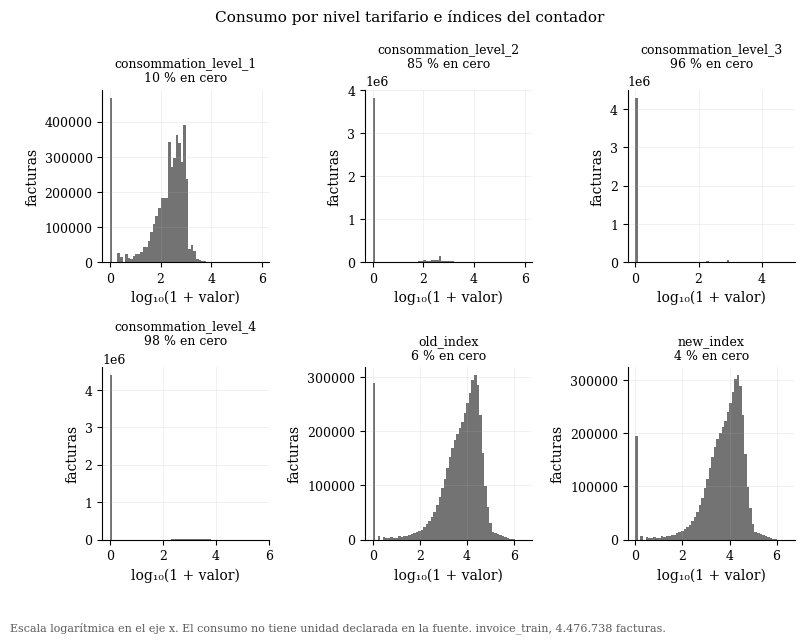

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=fg.FIGSIZE_GRID)
columnas = CONS + ["old_index", "new_index"]
for ax, col in zip(axes.ravel(), columnas):
    fg.plot_log_histogram(ax, invoice_train[col].to_numpy(), color=fg.COLOR_NEUTRAL)
    pct_cero = 100 * float((invoice_train[col] == 0).mean())
    ax.set_title(f"{col}\n{pct_cero:.0f} % en cero".replace(".", ","), fontsize=9)
    ax.set_xlabel("log₁₀(1 + valor)")
fig.suptitle("Consumo por nivel tarifario e índices del contador", fontsize=11)
fig.tight_layout()
fg.add_caption(fig, "Escala logarítmica en el eje x. El consumo no tiene unidad declarada "
                    "en la fuente. invoice_train, 4.476.738 facturas.")
fg.save_figure(fig, FIGURES / "fig_univ_consumo_indices.png")

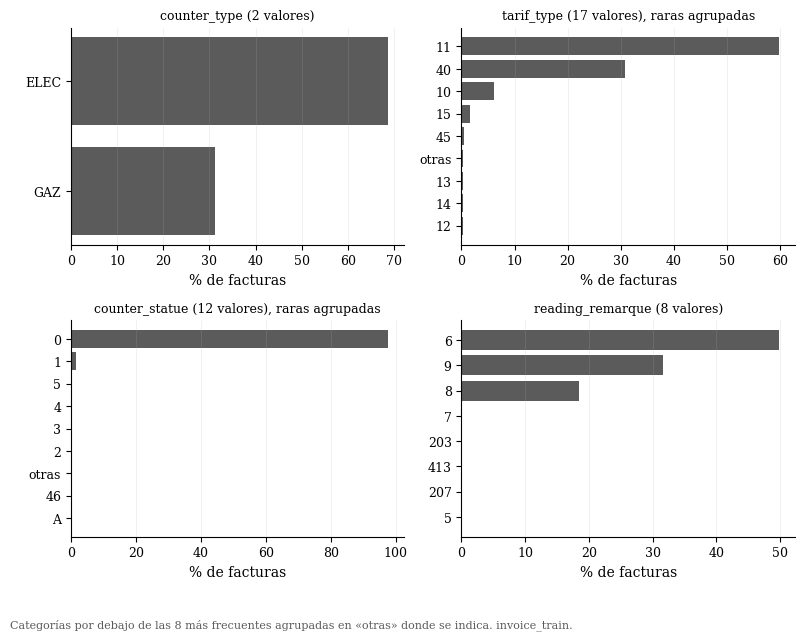

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=fg.FIGSIZE_GRID)
for ax, col in zip(axes.ravel(), ["counter_type", "tarif_type", "counter_statue",
                                  "reading_remarque"]):
    agrupada, agrupo = uni.maybe_group(invoice_train[col], top_k=8)
    vc = agrupada.value_counts()
    fg.plot_barh_frequency(ax, vc.index.tolist(), (100 * vc / len(invoice_train)).tolist(),
                           xlabel="% de facturas")
    ax.set_title(f"{col} ({invoice_train[col].nunique()} valores)" +
                 (", raras agrupadas" if agrupo else ""), fontsize=9)
fig.tight_layout()
fg.add_caption(fig, "Categorías por debajo de las 8 más frecuentes agrupadas en «otras» "
                    "donde se indica. invoice_train.")
fg.save_figure(fig, FIGURES / "fig_univ_categoricas.png")

In [ ]:
alta_card = []
for col in ["region", "counter_code", "counter_number", "tarif_type"]:
    vc = invoice_train[col].value_counts() if col != "region" else client_train[col].value_counts()
    n = len(invoice_train) if col != "region" else len(client_train)
    alta_card.append({
        "columna": col,
        "n_valores": int(len(vc)),
        "cuota_top1_pct": round(100 * vc.iloc[0] / n, 2),
        "cuota_top5_pct": round(100 * vc.head(5).sum() / n, 2),
        "n_valores_bajo_1pct": int((vc / n < 0.01).sum()),
    })
guardar(pd.DataFrame(alta_card), "univariate_high_cardinality")
display(pd.DataFrame(alta_card))

,columna,n_valores,cuota_top1_pct,cuota_top5_pct,n_valores_bajo_1pct
0,region,25,24.92,58.00,7
1,counter_code,42,33.88,92.63,35
2,counter_number,201893,0.96,0.98,201893
3,tarif_type,17,59.86,98.86,13


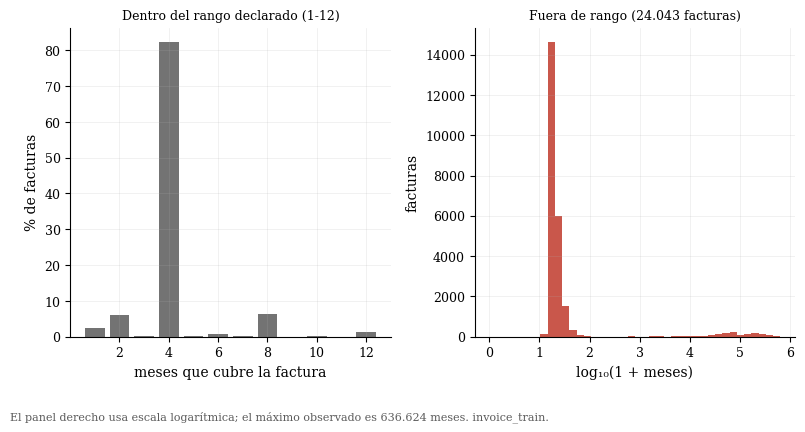

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=fg.FIGSIZE_WIDE)
validos = invoice_train.loc[invoice_train["months_number"].between(1, 12), "months_number"]
vc = validos.value_counts().sort_index()
axes[0].bar(vc.index, 100 * vc / len(invoice_train), color=fg.COLOR_NEUTRAL, alpha=0.85)
axes[0].set_xlabel("meses que cubre la factura")
axes[0].set_ylabel("% de facturas")
axes[0].set_title("Dentro del rango declarado (1-12)", fontsize=9)
fuera = invoice_train.loc[~invoice_train["months_number"].between(1, 12), "months_number"]
fg.plot_log_histogram(axes[1], fuera.to_numpy(), color=fg.COLOR_FRAUD, bins=40)
axes[1].set_xlabel("log₁₀(1 + meses)")
axes[1].set_title(f"Fuera de rango ({uni.mil(len(fuera))} facturas)", fontsize=9)
fig.tight_layout()
fg.add_caption(fig, "El panel derecho usa escala logarítmica; el máximo observado es "
                    "636.624 meses. invoice_train.")
fg.save_figure(fig, FIGURES / "fig_univ_months_number.png")

In [ ]:
cols_cli = ["disrict", "client_catg", "region"]
perfil_cli = uni.categorical_profile(client_train, cols_cli, "client_train", top_k=6)
guardar(perfil_cli, "univariate_client_categorical")

n_pos = int(client_train["target"].sum())
n_cli = len(client_train)
lo, hi = uni.wilson_interval(n_pos, n_cli)
print(f"clientes etiquetados como fraude: {uni.mil(n_pos)} de {uni.mil(n_cli)} "
      f"({100 * n_pos / n_cli:.2f} %, IC 95 % [{100 * lo:.2f} %, {100 * hi:.2f} %])")
print("altas por década:")
print((client_train["creation_date"].dt.year // 10 * 10).value_counts().sort_index().to_string())

clientes etiquetados como fraude: 7.566 de 135.493 (5.58 %, IC 95 % [5.46 %, 5.71 %])
altas por década:
creation_date
1970     4892
1980    20409
1990    24111
2000    39552
2010    46529


Las distribuciones de consumo están dominadas por la cola: `consommation_level_1` tiene
mediana 274 y máximo 999.910, con un sesgo que hace inútil cualquier estadístico basado en
la media. Los niveles 2 a 4 son cero en el 85 %, 96 % y 98 % de las facturas, de modo que
funcionan más como indicadores de haber superado un umbral que como variables continuas.
Los dos índices del contador tienen la misma forma y están relacionados por construcción,
lo que anticipa la colinealidad que se mide en la sección multivariada.

Entre las categóricas, `counter_statue` reparte el 97,8 % de las filas en un único código
y `counter_coefficient` vale 1 en el 99,97 %. Ninguna de las dos aporta variación
aprovechable tal cual, aunque su parte minoritaria pueda ser informativa. `region` tiene
25 valores con una cola de categorías que no llegan al 1 % de los clientes, lo que
condiciona cómo se codifiquen en la fase siguiente.

`client_catg` también es fuertemente asimétrica: el 97,05 % de los clientes cae en el
valor 11, mientras que 12 y 51 son categorías minoritarias (1,71 % y 1,24 % de los
clientes respectivamente). Esa concentración condiciona igual que `region` cómo se
codifique la variable en la fase siguiente.


## 5. Valores atípicos

Con distribuciones tan sesgadas, la pregunta no es cuántos atípicos hay, sino si son
errores de medición o el comportamiento que se busca detectar. El procedimiento es
cuantificarlos por el criterio intercuartílico, que no se deja arrastrar por la cola como
el z-score, y después comprobar su tasa de fraude antes de proponer cualquier tratamiento.

In [ ]:
atipicos = uni.numeric_profile(invoice_train, CONS + ["old_index", "new_index"], "invoice_train")
tabla_at = atipicos[["column", "p75", "iqr_upper_fence", "n_outliers_high_iqr",
                     "pct_outliers_high_iqr", "max"]]
guardar(tabla_at, "outliers_iqr")
display(tabla_at.round(2))

,column,p75,iqr_upper_fence,n_outliers_high_iqr,pct_outliers_high_iqr,max
0,consommation_level_1,600.0,1381.5,124585,2.78,999910.0
1,consommation_level_2,0.0,0.0,660570,14.76,999073.0
2,consommation_level_3,0.0,0.0,183358,4.10,64492.0
3,consommation_level_4,0.0,0.0,92958,2.08,547946.0
4,old_index,21660.0,51463.5,268597,6.00,2800280.0
5,new_index,22343.0,52773.5,266941,5.96,2870972.0


In [ ]:
# ¿Un consumo extremo es un error o una señal? Se mide a nivel de cliente, que es la
# unidad de análisis: comparte la cola del cliente con su etiqueta.
consumo_cliente = consumo_total.groupby(invoice_train["client_id"], observed=True).max()
objetivo = client_train.set_index("client_id")["target"].reindex(consumo_cliente.index).astype(int)
tramos_cons = pd.qcut(consumo_cliente.rank(method="first"), 10, labels=False)
filas = []
for tramo in sorted(pd.unique(tramos_cons.dropna())):
    m = tramos_cons == tramo
    k, n = int(objetivo[m].sum()), int(m.sum())
    lo_, hi_ = uni.wilson_interval(k, n)
    filas.append({"decil": int(tramo) + 1, "n": n, "consumo_max_min": float(consumo_cliente[m].min()),
                  "consumo_max_max": float(consumo_cliente[m].max()),
                  "tasa_fraude_pct": round(100 * k / n, 3),
                  "wilson_lo_pct": round(100 * lo_, 3), "wilson_hi_pct": round(100 * hi_, 3)})
tabla_out_target = guardar(pd.DataFrame(filas), "outliers_target_rate")
display(tabla_out_target)

,decil,n,consumo_max_min,consumo_max_max,tasa_fraude_pct,wilson_lo_pct,wilson_hi_pct
0,1,13550,0.0,269.0,0.649,0.527,0.799
1,2,13549,269.0,582.0,2.000,1.778,2.250
2,3,13549,582.0,827.0,3.838,3.527,4.175
3,4,13549,827.0,1061.0,4.384,4.052,4.742
4,5,13550,1061.0,1314.0,5.232,4.870,5.620
5,6,13549,1314.0,1626.0,5.809,5.427,6.215
6,7,13549,1627.0,2052.0,6.480,6.078,6.907
7,8,13549,2052.0,2724.0,7.144,6.723,7.590
8,9,13549,2724.0,4306.0,8.857,8.390,9.347
9,10,13550,4306.0,999910.0,11.446,10.921,11.994


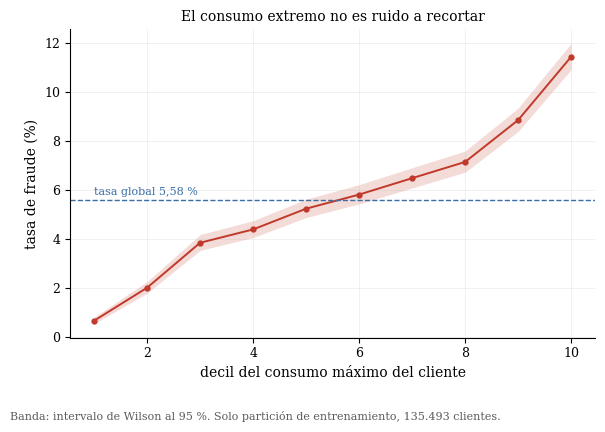

In [ ]:
base = 100 * float(objetivo.mean())
fig, ax = plt.subplots(figsize=fg.FIGSIZE_DEFAULT)
fg.plot_rate_by_bin(ax, tabla_out_target["decil"], tabla_out_target["tasa_fraude_pct"],
                    tabla_out_target["wilson_lo_pct"], tabla_out_target["wilson_hi_pct"],
                    xlabel="decil del consumo máximo del cliente", baseline=base)
ax.set_title("El consumo extremo no es ruido a recortar", fontsize=10)
fig.tight_layout()
fg.add_caption(fig, "Banda: intervalo de Wilson al 95 %. Solo partición de entrenamiento, "
                    "135.493 clientes.")
fg.save_figure(fig, FIGURES / "fig_outliers_target_rate.png")

Entre el 3 % y el 12 % de las facturas caen fuera del bigote superior según la columna,
con máximos tres órdenes de magnitud por encima del percentil 99. Un tratamiento
automático de atípicos habría recortado precisamente el tramo donde la tasa de fraude es
más alta: el decil superior de consumo máximo por cliente multiplica por varias veces la
tasa del decil inferior, y la relación es creciente en casi todo el recorrido.

De ahí que no se recorte ni se winsorice nada en esta fase. La propuesta para la etapa de
variables es transformar la escala, no truncar el rango: una transformación logarítmica
conserva el orden y hace manejable la cola, mientras que un recorte por percentil
destruiría la señal que el modelo necesita. Los valores extremos de `months_number` son
otro caso, porque ahí sí hay valores imposibles como período de facturación; esos se
tratan como anomalía de captura marcada, no como atípico de una distribución.

## 6. Estructura temporal

El historial abarca cuatro décadas, con una parte anterior a 2005. Dos preguntas gobiernan esta sección: cuánta información hay
realmente en cada tramo, y si la separación entre entrenamiento y prueba es temporal o
aleatoria, porque de eso depende qué protocolo de validación es honesto.

facturas anteriores a 2005: 22.112 (0.49 %)
media anual antes de 2005: 790
media anual desde 2005: 296.975


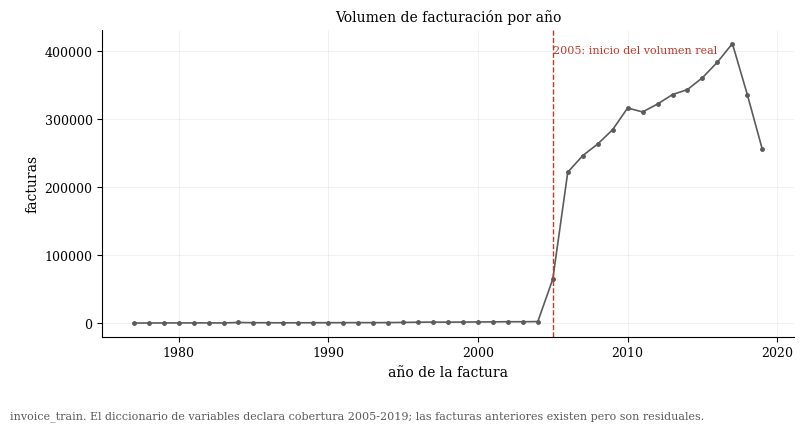

In [ ]:
por_anio = invoice_train["invoice_date"].dt.year.value_counts().sort_index()
guardar(por_anio.rename("facturas").reset_index().rename(columns={"index": "anio"}),
        "temporal_invoices_per_year")
pre = int(por_anio[por_anio.index < 2005].sum())
print(f"facturas anteriores a 2005: {uni.mil(pre)} ({100 * pre / len(invoice_train):.2f} %)")
print("media anual antes de 2005:", uni.mil(por_anio[por_anio.index < 2005].mean()))
print("media anual desde 2005:", uni.mil(por_anio[por_anio.index >= 2005].mean()))

fig, ax = plt.subplots(figsize=fg.FIGSIZE_WIDE)
fg.plot_year_series(ax, por_anio.index.tolist(), por_anio.values.tolist())
ax.set_title("Volumen de facturación por año", fontsize=10)
fig.tight_layout()
fg.add_caption(fig, "invoice_train. El diccionario de variables declara cobertura "
                    "2005-2019; las facturas anteriores existen pero son residuales.")
fg.save_figure(fig, FIGURES / "fig_temporal_invoices_per_year.png")

cuota del mes más cargado: 9.35 %
cuota del mes más flojo: 7.37 %


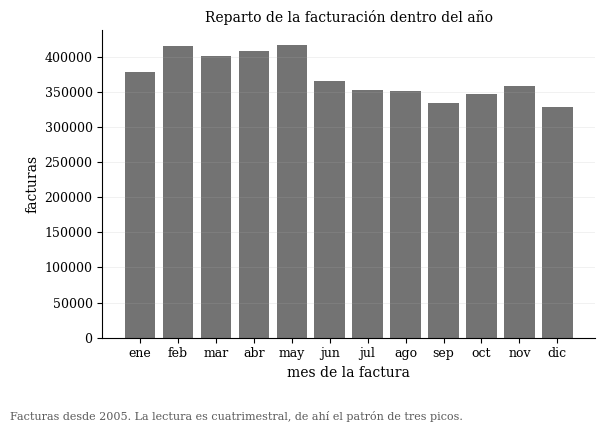

In [ ]:
fechas = invoice_train["invoice_date"]
por_mes = fechas[fechas.dt.year >= 2005].dt.month.value_counts().sort_index()
guardar(por_mes.rename("facturas").reset_index().rename(columns={"index": "mes"}),
        "temporal_seasonality_month")
fig, ax = plt.subplots(figsize=fg.FIGSIZE_DEFAULT)
fg.plot_month_profile(ax, por_mes.index.tolist(), por_mes.values.tolist())
ax.set_title("Reparto de la facturación dentro del año", fontsize=10)
fig.tight_layout()
fg.add_caption(fig, "Facturas desde 2005. La lectura es cuatrimestral, de ahí el patrón "
                    "de tres picos.")
fg.save_figure(fig, FIGURES / "fig_temporal_seasonality.png")
print("cuota del mes más cargado:", round(100 * por_mes.max() / por_mes.sum(), 2), "%")
print("cuota del mes más flojo:", round(100 * por_mes.min() / por_mes.sum(), 2), "%")

In [ ]:
cobertura = uni.per_client_temporal(invoice_train)
resumen_cob = uni.summarize_columns(
    cobertura, ["n_invoices", "span_years", "invoices_per_year",
                "median_gap_days_within_stream", "max_gap_days_within_stream"], "cliente")
guardar(resumen_cob, "temporal_client_coverage")
display(resumen_cob[["column", "p01", "p25", "p50", "p75", "p99", "max"]].round(1))

,column,p01,p25,p50,p75,p99,max
0,n_invoices,1.0,10.0,30.0,50.0,98.0,439.0
1,span_years,0.0,3.3,9.3,13.3,14.5,14.9
2,invoices_per_year,1.1,2.8,3.7,5.4,15.0,730.5
3,median_gap_days_within_stream,0.0,119.0,121.0,125.0,397.0,3518.0
4,max_gap_days_within_stream,62.0,256.0,364.0,450.0,1484.8,4208.0


In [ ]:
# ¿La partición de Zindi es temporal? Si lo fuera, el año de la última factura diferiría.
# invoice_test se carga solo para esta comparación y se libera: las dos tablas de
# facturas juntas ocupan memoria que el resto del cuaderno no necesita.
fechas_test = pd.read_parquet(INTERIM_FILES["invoice_test"],
                              columns=["client_id", "invoice_date"])
ultimo_tr = invoice_train.groupby("client_id")["invoice_date"].max().dt.year
ultimo_te = fechas_test.groupby("client_id")["invoice_date"].max().dt.year
comparacion = pd.DataFrame({
    "train_pct": 100 * ultimo_tr.value_counts(normalize=True),
    "test_pct": 100 * ultimo_te.value_counts(normalize=True),
}).sort_index().tail(8).round(2)
comparacion["dif_pp"] = (comparacion["train_pct"] - comparacion["test_pct"]).round(2)
guardar(comparacion.reset_index().rename(columns={"index": "anio_ultima_factura"}),
        "temporal_train_test_last_year")
display(comparacion)
print("mayor diferencia de cuota:", float(comparacion["dif_pp"].abs().max()), "puntos porcentuales")
del fechas_test

,train_pct,test_pct,dif_pp
invoice_date,,,
2012,1.16,1.17,-0.01
2013,1.04,1.09,-0.05
2014,1.07,1.08,-0.01
2015,1.27,1.27,0.00
2016,1.58,1.58,0.00
2017,3.19,3.03,0.16
2018,7.13,6.95,0.18
2019,70.61,71.09,-0.48


mayor diferencia de cuota: 0.48 puntos porcentuales


El volumen anterior a 2005 es residual: 24.795 facturas repartidas en 28 años, frente a
una media de 296.000 al año desde 2005. Ese tramo no sostiene ningún estadístico por año,
aunque sí alarga artificialmente la ventana de los clientes antiguos, que es justamente la
variable que la sección 9 identifica como determinante.

Dentro del año, la facturación se reparte en tres picos separados por cuatro meses, lo que
confirma la cadencia cuatrimestral que ya sugería `months_number`. La diferencia entre el
mes más cargado y el más flojo es de pocos puntos porcentuales, así que no hay
estacionalidad de consumo que corregir; lo que hay es un calendario de lectura.

La comparación del año de última factura entre las dos particiones responde la pregunta
del diseño: las cuotas coinciden hasta décimas de punto porcentual en todos los años. La
separación entre entrenamiento y prueba es aleatoria por cliente, no cronológica. Esto
tiene dos consecuencias directas. La validación interna debe imitar esa separación, es
decir agrupar por cliente sin corte temporal, y el desempeño que se mida no responde a la
pregunta de si el modelo detecta fraude futuro, limitación que corresponde declarar en el
manuscrito en vez de dejarla implícita.

## 7. Relación entre las dos tablas

Resumir el historial en una fila por cliente exige saber cuánta historia tiene cada uno y
qué tan comparable es entre clientes. Aquí se mide esa heterogeneidad, que resulta ser la
característica estructural más marcada del conjunto.

,tramo,clientes,pct
0,1,4212,3.11
1,2-3,11057,8.16
2,4-10,18662,13.77
3,11-30,35508,26.21
4,31-60,42592,31.43
5,>60,23462,17.32


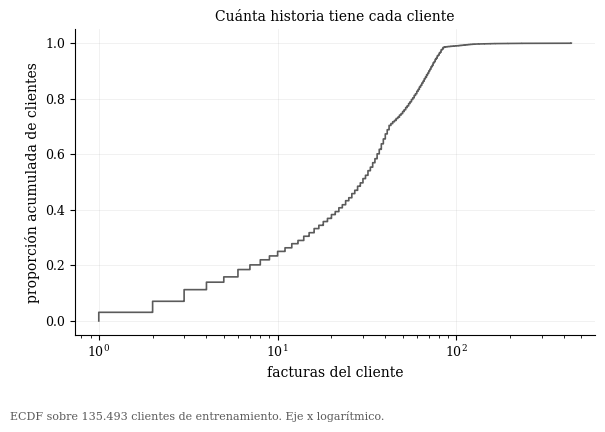

In [ ]:
n_facturas = cobertura.set_index("client_id")["n_invoices"]
tabla_hist = pd.DataFrame({
    "tramo": ["1", "2-3", "4-10", "11-30", "31-60", ">60"],
    "clientes": [int((n_facturas == 1).sum()), int(n_facturas.between(2, 3).sum()),
                 int(n_facturas.between(4, 10).sum()), int(n_facturas.between(11, 30).sum()),
                 int(n_facturas.between(31, 60).sum()), int((n_facturas > 60).sum())],
})
tabla_hist["pct"] = (100 * tabla_hist["clientes"] / len(n_facturas)).round(2)
guardar(tabla_hist, "relational_invoices_per_client")
display(tabla_hist)

fig, ax = plt.subplots(figsize=fg.FIGSIZE_DEFAULT)
fg.plot_ecdf(ax, n_facturas.to_numpy(), color=fg.COLOR_NEUTRAL)
ax.set_xlabel("facturas del cliente")
ax.set_xscale("log")
ax.set_title("Cuánta historia tiene cada cliente", fontsize=10)
fig.tight_layout()
fg.add_caption(fig, "ECDF sobre 135.493 clientes de entrenamiento. Eje x logarítmico.")
fg.save_figure(fig, FIGURES / "fig_relational_invoices_per_client.png")

In [ ]:
relacional = pd.DataFrame([
    {"medida": "clientes con una sola factura", "valor": int((n_facturas == 1).sum())},
    {"medida": "clientes con tres o menos", "valor": int((n_facturas <= 3).sum())},
    {"medida": "mediana de facturas por cliente", "valor": float(n_facturas.median())},
    {"medida": "máximo de facturas de un cliente", "valor": int(n_facturas.max())},
    {"medida": "clientes con dos tipos de contador", "valor": int((cobertura["n_streams"] == 2).sum())},
    {"medida": "clientes con primera factura anterior al alta", "valor": n_antes},
    {"medida": "mediana del intervalo entre lecturas del mismo contador (días)",
     "valor": float(cobertura["median_gap_days_within_stream"].median())},
])
guardar(relacional, "relational_summary")
display(relacional)

,medida,valor
0,clientes con una sola factura,4212.0
1,clientes con tres o menos,15269.0
2,mediana de facturas por cliente,30.0
3,máximo de facturas de un cliente,439.0
4,clientes con dos tipos de contador,61376.0
5,clientes con primera factura anterior al alta,8748.0
6,mediana del intervalo entre lecturas del mismo...,121.0


La dispersión del historial es el rasgo estructural que condiciona todo lo demás. La
mediana es de 30 facturas por cliente, pero 4.212 clientes tienen una sola y 15.269 tienen
tres o menos, mientras que el máximo llega a 439. Un resumen por cliente calculado sobre
una factura y otro calculado sobre cuatrocientas no son estadísticos comparables, aunque
ocupen la misma columna.

El 45 % de los clientes tiene contador eléctrico y de gas a la vez. Confundir ambas series
al calcular la cadencia de lectura haría parecer que a ese grupo se le lee el doble de
seguido, de modo que los intervalos se calculan dentro de cada tipo de contador; medidos
así, la mediana es de 121 días, coherente con la facturación cuatrimestral.

La fecha de alta es inconsistente con el historial en 8.748 clientes, cuya primera factura
antecede a su propia alta en una mediana de 75 días. Cualquier antigüedad calculada como
diferencia contra `creation_date` saldría negativa para ellos, así que conviene medirla
desde la primera factura observada.

## 8. Relación con la etiqueta

A partir de aquí todo corre sobre la partición de entrenamiento. La partición de prueba no
tiene etiqueta, y cruzar sus variables explicativas con la etiqueta de entrenamiento sería
fuga; las funciones que reciben `target` rechazan por construcción cualquier índice que no
sea de entrenamiento.

Medir la relación entre el historial de facturación y la etiqueta exige resumir cada
cliente en una fila. Los agregados que siguen son instrumentos de medición, no las
variables del modelo: sirven para cuantificar cuánta señal hay y dónde está, y se
descartan al terminar esta fase. Las variables definitivas se construyen más adelante, con
su propio diccionario y sus propias pruebas.

In [ ]:
COLS_AGG = ["client_id", "invoice_date", "counter_type", "counter_number", "counter_code",
            "tarif_type", "counter_statue", "counter_coefficient", "reading_remarque",
            "old_index", "new_index", "months_number"] + CONS + FLAGS


def agregados_exploratorios(inv: pd.DataFrame, cli: pd.DataFrame) -> pd.DataFrame:
    """Resume el historial de cada cliente en una fila.

    Instrumento de medición de señal para esta fase, no el conjunto de variables del
    modelo. Se ordena por cliente y tipo de contador porque los intervalos entre lecturas
    solo tienen sentido dentro de una misma serie.
    """
    d = inv[COLS_AGG].sort_values(["client_id", "counter_type", "invoice_date"])
    total = d[CONS].sum(axis=1)
    d = d.assign(
        cons_total=total,
        delta_index=d["new_index"] - d["old_index"],
        gap=d.groupby(["client_id", "counter_type"], observed=True)["invoice_date"].diff().dt.days,
        statue_nonzero=(d["counter_statue"] != "0").astype(bool),
        coef_gt1=(d["counter_coefficient"] > 1).astype(bool),
        levels_mismatch=(total != (d["new_index"] - d["old_index"])).astype(bool),
        cons_cero=(total == 0).astype(bool),
    )
    g = d.groupby("client_id", observed=True)
    out = pd.DataFrame({
        "exp_n_invoices": g.size(),
        "exp_n_counters": g["counter_number"].nunique(),
        "exp_n_counter_types": g["counter_type"].nunique(),
        "exp_n_tarif_types": g["tarif_type"].nunique(),
        "exp_n_counter_codes": g["counter_code"].nunique(),
        "exp_cons_total_median": g["cons_total"].median(),
        "exp_cons_total_mean": g["cons_total"].mean(),
        "exp_cons_total_max": g["cons_total"].max(),
        "exp_cons_total_std": g["cons_total"].std(),
        "exp_cons1_median": g["consommation_level_1"].median(),
        "exp_cons2_mean": g["consommation_level_2"].mean(),
        "exp_cons3_mean": g["consommation_level_3"].mean(),
        "exp_cons4_mean": g["consommation_level_4"].mean(),
        "exp_delta_index_median": g["delta_index"].median(),
        "exp_new_index_max": g["new_index"].max(),
        "exp_months_number_mean": g["months_number"].mean(),
        "exp_gap_median_days": g["gap"].median(),
        "exp_gap_max_days": g["gap"].max(),
        "exp_share_cons_cero": g["cons_cero"].mean(),
        "exp_share_statue_nonzero": g["statue_nonzero"].mean(),
        "exp_share_coef_gt1": g["coef_gt1"].mean(),
        "exp_share_levels_mismatch": g["levels_mismatch"].mean(),
        "exp_first_invoice": g["invoice_date"].min(),
        "exp_last_invoice": g["invoice_date"].max(),
    })
    for flag in FLAGS:
        out[f"exp_share_{flag}"] = g[flag].mean()
    out["exp_span_days"] = (out["exp_last_invoice"] - out["exp_first_invoice"]).dt.days
    out["exp_invoices_per_year"] = np.where(
        out["exp_span_days"] > 0, out["exp_n_invoices"] / (out["exp_span_days"] / 365.25), np.nan)
    out["exp_days_since_last"] = (inv["invoice_date"].max() - out["exp_last_invoice"]).dt.days
    out["exp_cv_cons"] = out["exp_cons_total_std"] / out["exp_cons_total_mean"].replace(0, np.nan)
    alta_cli = cli.set_index("client_id")["creation_date"].reindex(out.index)
    out["exp_antiguedad_dias"] = (out["exp_last_invoice"] - alta_cli).dt.days
    out["exp_creation_year"] = alta_cli.dt.year
    out["exp_counters_por_factura"] = out["exp_n_counters"] / out["exp_n_invoices"]
    return out.drop(columns=["exp_first_invoice", "exp_last_invoice"])


X_train = agregados_exploratorios(invoice_train, client_train)
y_train = (client_train.set_index("client_id")["target"]
           .reindex(X_train.index).astype("int8"))
X_train = X_train.loc[y_train.index]
assert X_train.index.equals(y_train.index)
print("agregados exploratorios:", X_train.shape, "| positivos:", int(y_train.sum()))

agregados exploratorios: (135493, 34) | positivos: 7566


In [ ]:
diccionario = pd.DataFrame({
    "variable": X_train.columns,
    "dtype": [str(X_train[c].dtype) for c in X_train.columns],
    "n_faltantes": [int(X_train[c].isna().sum()) for c in X_train.columns],
    "descripcion": [
        {"exp_n_invoices": "facturas del cliente",
         "exp_n_counters": "valores distintos de counter_number",
         "exp_n_counter_types": "tipos de contador (ELEC, GAZ)",
         "exp_n_tarif_types": "tipos de tarifa distintos",
         "exp_n_counter_codes": "valores distintos de counter_code",
         "exp_cons_total_median": "mediana del consumo total por factura",
         "exp_cons_total_mean": "media del consumo total por factura",
         "exp_cons_total_max": "consumo máximo en una factura",
         "exp_cons_total_std": "desviación del consumo entre facturas",
         "exp_cons1_median": "mediana del consumo de nivel 1",
         "exp_cons2_mean": "media del consumo de nivel 2",
         "exp_cons3_mean": "media del consumo de nivel 3",
         "exp_cons4_mean": "media del consumo de nivel 4",
         "exp_delta_index_median": "mediana de new_index - old_index",
         "exp_new_index_max": "lectura máxima alcanzada",
         "exp_months_number_mean": "meses medios cubiertos por factura",
         "exp_gap_median_days": "mediana de días entre lecturas del mismo contador",
         "exp_gap_max_days": "máximo de días entre lecturas del mismo contador",
         "exp_share_cons_cero": "proporción de facturas sin consumo",
         "exp_share_statue_nonzero": "proporción con counter_statue distinto de 0",
         "exp_share_coef_gt1": "proporción con coeficiente mayor que 1",
         "exp_share_levels_mismatch": "proporción donde los niveles no cuadran con el índice",
         "exp_span_days": "días entre la primera y la última factura",
         "exp_invoices_per_year": "facturas por año de historial",
         "exp_days_since_last": "días desde la última factura hasta el cierre del panel",
         "exp_cv_cons": "coeficiente de variación del consumo",
         "exp_antiguedad_dias": "días entre el alta declarada y la última factura",
         "exp_creation_year": "año de alta del cliente",
         "exp_counters_por_factura": "contadores distintos por factura"}.get(
            c, f"proporción de facturas marcadas por {c.replace('exp_share_', '')}")
        for c in X_train.columns],
})
guardar(diccionario, "exploratory_aggregate_dictionary")
print(f"{len(diccionario)} agregados exploratorios; "
      f"{int((diccionario['n_faltantes'] > 0).sum())} con algún faltante")

34 agregados exploratorios; 5 con algún faltante


In [ ]:
cat_cliente = client_train.set_index("client_id").loc[y_train.index]
asociacion = []
for col in ["disrict", "client_catg", "region"]:
    r = biv.categorical_vs_target(cat_cliente[col], y_train, col, top_k=12)
    asociacion.append(r)
tabla_cat = guardar(pd.DataFrame(asociacion)[
    ["variable", "n_categories", "cramers_v_bias_corrected", "chi2", "p_value",
     "min_expected", "pct_cells_expected_lt5", "n"]], "bivariate_categorical_target")
display(tabla_cat.round(4))

,variable,n_categories,cramers_v_bias_corrected,chi2,p_value,min_expected,pct_cells_expected_lt5,n
0,disrict,4,0.0582,462.5873,0.0,1618.6492,0.0,135493
1,client_catg,3,0.0555,419.9298,0.0,93.7004,0.0,135493
2,region,13,0.0819,920.0288,0.0,213.7575,0.0,135493


,variable,category,n,n_pos,rate_pct,wilson_lo_pct,wilson_hi_pct,lift_vs_base,base_rate_pct
0,disrict,69,34231,2447,7.15,6.88,7.43,1.28,5.58
1,disrict,63,28987,1891,6.52,6.25,6.81,1.17,5.58
2,disrict,62,40353,2083,5.16,4.95,5.38,0.92,5.58
3,disrict,60,31922,1145,3.59,3.39,3.80,0.64,5.58
4,client_catg,51,1678,283,16.87,15.15,18.73,3.02,5.58
5,client_catg,11,131494,7191,5.47,5.35,5.59,0.98,5.58
6,client_catg,12,2321,92,3.96,3.24,4.84,0.71,5.58


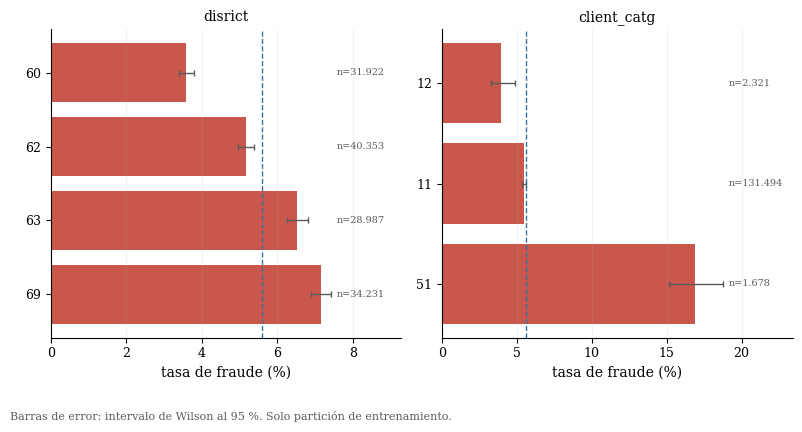

In [ ]:
tasas = pd.concat([biv.target_rate_by_category(cat_cliente[c], y_train, c, top_k=12)
                   for c in ["disrict", "client_catg"]], ignore_index=True)
tasas_region = biv.target_rate_by_category(cat_cliente["region"], y_train, "region")
guardar(pd.concat([tasas, tasas_region], ignore_index=True), "bivariate_category_rates")
base_pct = 100 * float(y_train.mean())

fig, axes = plt.subplots(1, 2, figsize=fg.FIGSIZE_WIDE)
for ax, col in zip(axes, ["disrict", "client_catg"]):
    sub = tasas[tasas["variable"] == col]
    fg.plot_rate_with_ci(ax, sub["category"], sub["rate_pct"], sub["wilson_lo_pct"],
                         sub["wilson_hi_pct"], sub["n"], baseline=base_pct)
    ax.set_title(col, fontsize=10)
fig.tight_layout()
fg.add_caption(fig, "Barras de error: intervalo de Wilson al 95 %. Solo partición de "
                    "entrenamiento.")
fg.save_figure(fig, FIGURES / "fig_biv_tasas_categoricas.png")
display(tasas.round(2))

recorrido de la tasa entre las 25 regiones: 0.00 % a 10.30 %
regiones con menos de 100 clientes: 2


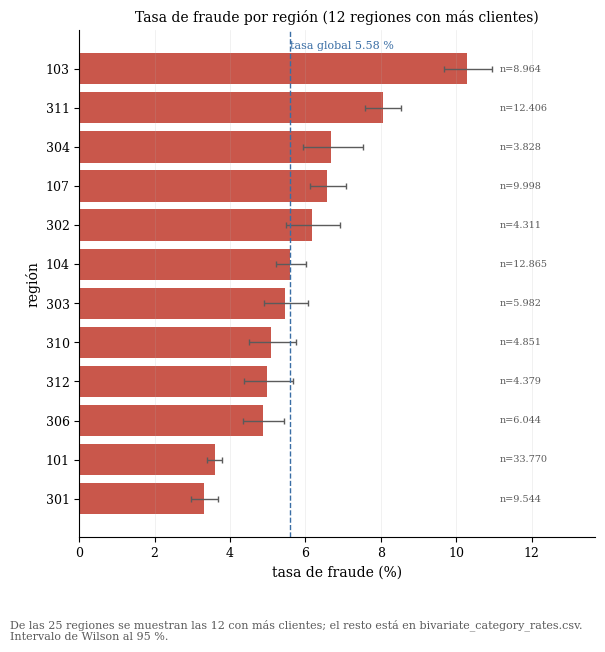

In [ ]:
top_region = tasas_region.sort_values("n", ascending=False).head(12).sort_values("rate_pct")
fig, ax = plt.subplots(figsize=fg.FIGSIZE_TALL)
fg.plot_rate_with_ci(ax, top_region["category"], top_region["rate_pct"],
                     top_region["wilson_lo_pct"], top_region["wilson_hi_pct"],
                     top_region["n"], baseline=base_pct)
ax.set_ylabel("región")
ax.set_title("Tasa de fraude por región (12 regiones con más clientes)", fontsize=10)
fig.tight_layout()
fg.add_caption(fig, "De las 25 regiones se muestran las 12 con más clientes; el resto "
                    "está en bivariate_category_rates.csv. Intervalo de Wilson al 95 %.")
fg.save_figure(fig, FIGURES / "fig_biv_tasas_region.png")
print("recorrido de la tasa entre las 25 regiones: "
      f"{tasas_region['rate_pct'].min():.2f} % a {tasas_region['rate_pct'].max():.2f} %")
print("regiones con menos de 100 clientes:", int((tasas_region["n"] < 100).sum()))

In [ ]:
cols_num = list(X_train.columns)
efectos = biv.numeric_table_vs_target(X_train[cols_num].astype("float64"), y_train, cols_num)
guardar(efectos, "bivariate_numeric_target")
display(efectos[["variable", "n", "median_neg", "median_pos", "rank_biserial",
                 "ci95_lo", "ci95_hi", "above_threshold"]].head(15).round(4))
print("agregados por encima del umbral de |rank-biserial| = 0,1:",
      int(efectos["above_threshold"].sum()), "de", len(efectos))

KeyboardInterrupt: 

In [ ]:
top = efectos.head(14).iloc[::-1]
fig, ax = plt.subplots(figsize=fg.FIGSIZE_TALL)
fg.plot_forest(ax, top["variable"], top["rank_biserial"], top["ci95_lo"], top["ci95_hi"],
               xlabel="rank-biserial (0 = clases indistinguibles)",
               threshold=biv.EFFECT_SIZE_THRESHOLD)
ax.set_title("Tamaño de efecto de cada agregado frente a la etiqueta", fontsize=10)
fig.tight_layout()
fg.add_caption(fig, "Intervalo por bootstrap de 1.000 remuestreos sobre clientes. Línea "
                    "punteada: umbral de 0,1 por debajo del cual el efecto se considera "
                    "ruido de muestra grande.")
fg.save_figure(fig, FIGURES / "fig_biv_tamanos_efecto.png")

In [ ]:
banderas = []
for flag in FLAGS:
    col = X_train[f"exp_share_{flag}"] > 0
    banderas.append(biv.binary_flag_vs_target(col, y_train, flag))
tabla_flags = guardar(pd.DataFrame(banderas), "bivariate_flags_target")
display(tabla_flags[["variable", "n_flagged", "rate_flagged_pct", "rate_not_flagged_pct",
                     "risk_ratio", "rr_ci95_lo", "rr_ci95_hi"]].round(3))

fig, ax = plt.subplots(figsize=fg.FIGSIZE_DEFAULT)
orden = tabla_flags.sort_values("risk_ratio")
fg.plot_forest(ax, orden["variable"], orden["risk_ratio"] - 1, orden["rr_ci95_lo"] - 1,
               orden["rr_ci95_hi"] - 1, xlabel="riesgo relativo - 1 (0 = sin diferencia)")
ax.set_title("¿Las anomalías de captura se concentran en clientes con fraude?", fontsize=10)
fig.tight_layout()
fg.add_caption(fig, "Cliente marcado = al menos una factura con la anomalía. Intervalo "
                    "logarítmico al 95 %.")
fg.save_figure(fig, FIGURES / "fig_biv_banderas.png")

In [ ]:
# El estimador de información mutua es de vecinos más próximos y no escala a 135.493
# filas por 34 columnas repetido seis veces. Se usa una submuestra de clientes con
# semilla fija; el nulo de permutación se calcula sobre la misma submuestra, así que la
# comparación observado/nulo sigue siendo válida.
sub = X_train.sample(n=40_000, random_state=SEED).index.sort_values()
mi = biv.mutual_information_ranking(X_train.loc[sub, cols_num].astype("float64"),
                                    y_train.loc[sub], n_permutations=3)
guardar(mi, "bivariate_mutual_information")
display(mi.head(10).round(6))
print("agregados por encima del máximo del nulo de permutación:",
      int(mi["above_null_max"].sum()), "de", len(mi))

Tres resultados ordenan la lectura de esta sección.

El primero es que la categoría de cliente discrimina con fuerza. La categoría 51 tiene una
tasa de fraude del 16,9 % frente al 5,58 % global, con 1.678 clientes detrás, y el
intervalo de Wilson no se acerca a la tasa base. El distrito y la región también separan:
entre las 25 regiones la tasa recorre desde menos del 1 % hasta más del 10 %. Aun así, la
Cramér's V corregida se queda por debajo de 0,1 en las tres variables, lo que significa
que la asociación existe pero explica una fracción pequeña de la variación; son variables
que aportan contexto, no un clasificador por sí solas.

El segundo es que los agregados con más señal describen el tamaño del historial antes que
el comportamiento de consumo. El número de contadores distintos, el número de facturas, la
amplitud temporal del historial y la lectura máxima alcanzada encabezan la lista con
rank-biserial entre 0,30 y 0,42, mientras que la mediana del consumo se queda en 0,06. Es
un resultado incómodo y merece investigación propia, que es lo que hace la sección
siguiente.

El tercero es que dos de las cinco banderas de anomalía sí separan. Un cliente con al
menos una factura duplicada por clave lógica tiene un 11,8 % de fraude frente al 5,5 % del
resto, riesgo relativo 2,16 con intervalo [1,92, 2,42]; con al menos un retroceso de índice
la cifra es casi la misma. `months_number` fuera de rango apenas llega a 1,17, y las dos
banderas de captura corrida afectan a tan pocos clientes que no admiten estimación.

Ese resultado hay que tomarlo con la misma cautela que el anterior. «Tener al menos una
anomalía» es mecánicamente más probable cuanto más larga es la historia del cliente, así
que el riesgo doble podría ser el mismo efecto de exposición disfrazado. La sección
siguiente lo comprueba en vez de darlo por bueno.

## 9. Longitud del historial como factor de confusión

El resultado anterior obliga a detenerse. Si las variables que mejor separan las clases son
las que miden cuánta historia tiene un cliente, hay dos explicaciones posibles y llevan a
conclusiones opuestas. Una es que los defraudadores sean efectivamente clientes antiguos
con más contadores. La otra es que un cliente con más historial haya tenido más ocasiones
de ser inspeccionado, y por tanto más probabilidad de aparecer etiquetado como fraude
aunque su comportamiento sea idéntico al de otro con historial corto.

Distinguirlas importa porque la etiqueta no registra fraude cometido sino fraude detectado.
Lo que sigue mide la magnitud del gradiente y comprueba si el resto de las variables
conserva su efecto cuando se compara a clientes con historiales de longitud parecida.

In [ ]:
decil = pd.qcut(X_train["exp_n_invoices"].rank(method="first"), 10, labels=False)
filas = []
for d_ in sorted(pd.unique(decil)):
    m = decil == d_
    k, n = int(y_train[m].sum()), int(m.sum())
    lo_, hi_ = uni.wilson_interval(k, n)
    filas.append({"decil": int(d_) + 1, "n": n,
                  "facturas_min": int(X_train.loc[m, "exp_n_invoices"].min()),
                  "facturas_max": int(X_train.loc[m, "exp_n_invoices"].max()),
                  "tasa_fraude_pct": round(100 * k / n, 3),
                  "wilson_lo_pct": round(100 * lo_, 3),
                  "wilson_hi_pct": round(100 * hi_, 3)})
gradiente = guardar(pd.DataFrame(filas), "confounding_history_length")
display(gradiente)
razon = gradiente["tasa_fraude_pct"].iloc[-1] / gradiente["tasa_fraude_pct"].iloc[0]
print(f"el decil con más historial multiplica por {razon:.1f} la tasa del decil con menos")

In [ ]:
fig, ax = plt.subplots(figsize=fg.FIGSIZE_DEFAULT)
fg.plot_rate_by_bin(ax, gradiente["decil"], gradiente["tasa_fraude_pct"],
                    gradiente["wilson_lo_pct"], gradiente["wilson_hi_pct"],
                    xlabel="decil de facturas acumuladas por el cliente", baseline=base_pct)
ax.set_title("La tasa de fraude crece con la longitud del historial", fontsize=10)
fig.tight_layout()
fg.add_caption(fig, "Deciles de exp_n_invoices sobre 135.493 clientes de entrenamiento. "
                    "Banda: intervalo de Wilson al 95 %.")
fg.save_figure(fig, FIGURES / "fig_confusion_historial.png")

In [ ]:
quintil = pd.qcut(X_train["exp_n_invoices"].rank(method="first"), 5, labels=False)
examinadas = ["exp_n_counters", "exp_cons_total_max", "exp_new_index_max", "exp_cons2_mean",
              "exp_cv_cons", "exp_antiguedad_dias", "exp_cons_total_median",
              "exp_share_statue_nonzero"]
filas = []
for var in examinadas:
    fila = {"variable": var,
            "global": float(efectos.loc[efectos["variable"] == var, "rank_biserial"].iloc[0])}
    for q in sorted(pd.unique(quintil)):
        m = quintil == q
        fila[f"q{int(q) + 1}"] = round(
            biv.numeric_vs_target(X_train.loc[m, var].astype("float64"), y_train[m], var,
                                  n_boot=1)["rank_biserial"], 4)
    filas.append(fila)
condicional = guardar(pd.DataFrame(filas), "confounding_conditional_effects")
display(condicional.round(3))

In [ ]:
fig, ax = plt.subplots(figsize=fg.FIGSIZE_WIDE)
qcols = [c for c in condicional.columns if c.startswith("q")]
matriz = condicional[["global"] + qcols].to_numpy()
fg.plot_heatmap(ax, matriz, condicional["variable"].tolist(),
                ["global"] + [f"quintil {i + 1}" for i in range(len(qcols))],
                cbar_label="rank-biserial", annotate=True, vmin=-0.1, vmax=0.55)
ax.set_title("Efecto de cada variable dentro de estratos de longitud de historial", fontsize=10)
fig.tight_layout()
fg.add_caption(fig, "Quintiles de exp_n_invoices. Un efecto que se desvanece al pasar del "
                    "global al estrato estaba explicado por la longitud del historial.")
fg.save_figure(fig, FIGURES / "fig_confusion_condicional.png")

In [ ]:
# ¿El riesgo doble de las banderas es señal o efecto de tener más facturas? Si lo primero,
# la proporción de facturas anómalas del cliente debería discriminar tanto como la marca
# binaria; si lo segundo, la proporción no dirá nada.
filas = []
for flag in FLAGS:
    prop = f"exp_share_{flag}"
    rb = float(efectos.loc[efectos["variable"] == prop, "rank_biserial"].iloc[0])
    fila = {"bandera": flag,
            "rr_al_menos_una": float(tabla_flags.loc[tabla_flags["variable"] == flag,
                                                     "risk_ratio"].iloc[0]),
            "rank_biserial_de_la_proporcion": round(rb, 4),
            "proporcion_supera_umbral": bool(abs(rb) >= biv.EFFECT_SIZE_THRESHOLD)}
    for q in sorted(pd.unique(quintil)):
        m = quintil == q
        fila[f"rr_q{int(q) + 1}"] = biv.binary_flag_vs_target(
            X_train.loc[m, prop] > 0, y_train[m], flag)["risk_ratio"]
    filas.append(fila)
flags_cond = guardar(pd.DataFrame(filas), "confounding_flags")
display(flags_cond)

In [ ]:
cruce = (pd.crosstab(cat_cliente["disrict"], cat_cliente["client_catg"], y_train,
                     aggfunc="mean") * 100).round(2)
conteo = pd.crosstab(cat_cliente["disrict"], cat_cliente["client_catg"])
guardar(cruce.reset_index(), "multivariate_disrict_catg", index=False)
fig, ax = plt.subplots(figsize=fg.FIGSIZE_DEFAULT)
fg.plot_heatmap(ax, cruce.to_numpy(), [str(i) for i in cruce.index],
                [str(c) for c in cruce.columns], cbar_label="tasa de fraude (%)",
                annotate=True, fmt="{:.1f}")
ax.set_xlabel("categoría de cliente")
ax.set_ylabel("distrito")
ax.set_title("¿La categoría 51 concentra el riesgo en algún distrito?", fontsize=10)
fig.tight_layout()
fg.add_caption(fig, "Celdas con menos de 100 clientes tienen intervalo muy ancho; el "
                    "conteo por celda va en multivariate_disrict_catg_n.csv.")
fg.save_figure(fig, FIGURES / "fig_multi_disrict_catg.png")
guardar(conteo.reset_index(), "multivariate_disrict_catg_n", index=False)
display(conteo)

In [ ]:
corr = biv.spearman_matrix(invoice_train, CONS + ["old_index", "new_index", "months_number"],
                           sample=200_000)
guardar(corr.round(4).reset_index(), "multivariate_spearman_consumo", index=False)
fig, ax = plt.subplots(figsize=fg.FIGSIZE_TALL)
fg.plot_heatmap(ax, corr.to_numpy(), corr.index.tolist(), corr.columns.tolist(),
                cbar_label="Spearman", annotate=True, vmin=-1, vmax=1, cmap="viridis")
ax.set_title("Correlación entre las variables de consumo e índices", fontsize=10)
fig.tight_layout()
fg.add_caption(fig, "Spearman sobre una submuestra de 200.000 facturas con semilla fija. "
                    "old_index y new_index están ligados por construcción.")
fg.save_figure(fig, FIGURES / "fig_multi_spearman.png")
print("correlación old_index / new_index:", round(float(corr.loc["old_index", "new_index"]), 4))

El gradiente es la estructura más fuerte del conjunto. Entre el decil de clientes con menos
facturas y el de más, la tasa de fraude pasa del 0,7 % al 9,8 %, un factor de catorce. La
progresión es monótona salvo un escalón, y los intervalos de Wilson de los deciles extremos
no se solapan ni de lejos.

El análisis condicional separa las dos explicaciones. `exp_new_index_max` pierde todo su
efecto dentro de estratos de longitud comparable, pasando de 0,31 global a valores cercanos
a cero en el quintil superior: lo que medía era acumulación de lecturas a lo largo del
tiempo, no consumo anómalo. En cambio `exp_n_counters` conserva entre 0,22 y 0,40 en todos
los quintiles, así que el número de contadores distintos dice algo que la longitud del
historial no explica. El consumo máximo y el consumo de nivel 2 quedan en una posición
intermedia, con efectos que se reducen a la mitad pero no desaparecen.

La interpretación que sostiene la evidencia es que la etiqueta mide fraude detectado, y la
detección depende de haber sido inspeccionado alguna vez. Un cliente con cuatrocientas
facturas ha estado expuesto a muchas más visitas que uno con tres. Esto no invalida el
problema, pero sí condiciona tres cosas: cualquier variable de volumen acumulado debe
mirarse con sospecha en la fase siguiente, la interpretación de importancias en la fase de
explicabilidad tiene que distinguir señal de exposición, y el desempeño desagregado por
longitud de historial pasa a ser un control obligatorio y no un extra.

Las dos banderas que parecían discriminar resisten mal el examen, aunque no por completo.
Medida como proporción de las facturas del cliente, la duplicación por clave lógica da un
rank-biserial de 0,019 y el retroceso de índice 0,015, los dos muy por debajo del umbral de
0,1: la frecuencia con la que un cliente acumula anomalías no dice nada sobre su etiqueta.
La marca binaria conserva riesgo dentro de los estratos, pero se atenúa según crece el
historial, de 2,31 en el quintil más corto a 1,26 en el más largo
(`confounding_flags.csv`), que es el patrón esperable si «tener al menos una» mide sobre
todo cuántas facturas hay. Si la fase de variables recupera estas anomalías, tendrá que ser
en forma de tasa y compitiendo contra la longitud del historial, no como marca binaria.

La colinealidad entre índices confirma lo esperado: `old_index` y `new_index` correlacionan
a 0,99 en Spearman, de modo que usarlos como variables independientes sería redundante. El
cruce entre distrito y categoría de cliente muestra que la categoría 51 mantiene su exceso
de riesgo en los cuatro distritos, con lo que no es un artefacto geográfico.

## 10. Comparabilidad entre las dos particiones

Si las variables se distribuyeran de forma distinta entre entrenamiento y prueba, cualquier
desempeño medido internamente dejaría de ser informativo sobre la prueba. La verificación
usa Kolmogorov-Smirnov para las continuas y Cramér's V para las categóricas, con el valor
crítico y la diferencia de cuota como referencia, porque con cientos de miles de filas el
p-valor rechaza por diferencias irrelevantes.

In [ ]:
invoice_test = pd.read_parquet(INTERIM_FILES["invoice_test"])
client_test = pd.read_parquet(INTERIM_FILES["client_test"])
X_test = agregados_exploratorios(invoice_test, client_test)

comparaciones = []
for col in ["exp_n_invoices", "exp_span_days", "exp_cons_total_median", "exp_cons_total_max",
            "exp_n_counters", "exp_gap_median_days"]:
    comparaciones.append(uni.compare_numeric(X_train[col], X_test[col], col, "cliente"))
for col in ["consommation_level_1", "new_index", "months_number"]:
    comparaciones.append(uni.compare_numeric(invoice_train[col], invoice_test[col], col,
                                             "factura"))
for col in ["disrict", "client_catg", "region"]:
    comparaciones.append(uni.compare_categorical(client_train[col], client_test[col], col,
                                                 "cliente"))
for col in ["tarif_type", "counter_type", "counter_statue"]:
    comparaciones.append(uni.compare_categorical(invoice_train[col], invoice_test[col], col,
                                                 "factura"))
traintest = guardar(pd.DataFrame(comparaciones), "traintest_comparison")
display(traintest[["level", "column", "effect_size_name", "effect_size", "reference_name",
                   "reference", "max_abs_share_diff_pp"]].round(4))

In [ ]:
continuas = traintest[traintest["effect_size_name"] == "D"].sort_values("effect_size")
fig, ax = plt.subplots(figsize=fg.FIGSIZE_DEFAULT)
y_pos = np.arange(len(continuas))
ax.barh(y_pos, continuas["effect_size"], color=fg.COLOR_TRAIN, alpha=0.85,
        label="D observado")
ax.plot(continuas["reference"], y_pos, "o", color=fg.COLOR_FRAUD, markersize=4,
        label="D crítico al 5 %")
ax.set_yticks(y_pos)
ax.set_yticklabels(continuas["column"])
ax.set_xlabel("estadístico D de Kolmogorov-Smirnov")
ax.grid(axis="y", visible=False)
ax.legend(loc="lower right")
ax.set_title("Diferencia de distribución entre entrenamiento y prueba", fontsize=10)
fig.tight_layout()
fg.add_caption(fig, "Submuestra de 200.000 observaciones por lado con semilla fija donde "
                    "la columna lo exige. Un D por encima del crítico indica diferencia "
                    "detectable, cuya magnitud práctica hay que leer aparte.")
fg.save_figure(fig, FIGURES / "fig_traintest_ks.png")
print("mayor diferencia de cuota en categóricas:",
      round(float(traintest["max_abs_share_diff_pp"].max()), 3), "puntos porcentuales")
del invoice_test

Las dos particiones son comparables. En las categóricas, la mayor diferencia de cuota entre
entrenamiento y prueba es de 0,66 puntos porcentuales y las Cramér's V quedan en el orden de
0,01, valores sin relevancia práctica. En las continuas, varios estadísticos D superan el
crítico al 5 %, lo que era previsible con muestras de este tamaño; las magnitudes se mueven
en torno a 0,01, es decir un desplazamiento del uno por ciento de la masa de probabilidad.

La única asimetría real es de categorías raras: la región 199, el tipo de tarifa 18 y tres
códigos de contador aparecen solo en entrenamiento. Entre las cuatro afectan a un puñado de
clientes, pero fijan un requisito para la codificación de categóricas de la fase siguiente,
que tendrá que resolver qué hacer con una categoría no vista sin fallar en predicción.